<a href="https://colab.research.google.com/github/clarachence/prova_11_clara_chence/blob/main/neuroalgoritmos_clara_chence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 11: NVDA (Nvidia) | Gap de Fuga

**Alvo ($Y$):** 1 se a abertura de hoje superar a máxima (high) de ontem; 0 caso contrário.

**Desafio:** Analisar o comportamento do classificador frente a movimentos exponenciais.

**Aluna:** Clara Chence

# 1. CONFIGURAÇÃO E EXTRAÇÃO


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

In [5]:
API_KEY = 'VJY5CWLZK2SN5J53'
simbolo = 'NVDA'
url = (
    f'https://www.alphavantage.co/query'
    f'?function=TIME_SERIES_DAILY'
    f'&symbol={simbolo}'
    f'&outputsize=compact'
    f'&apikey={API_KEY}'
)

dados = requests.get(url).json()
serie = dados.get('Time Series (Daily)', {})
df = pd.DataFrame.from_dict(serie, orient='index')
df.index = pd.to_datetime(df.index)
df = df.sort_index().astype(float)
df.columns = ['abertura', 'maxima', 'minima', 'fechamento', 'volume']

print(f"Registros: {len(df)} | Período: {df.index.min().date()} até {df.index.max().date()}")
df.head()

Registros: 100 | Período: 2026-01-28 até 2026-06-22


,abertura,maxima,minima,fechamento,volume
2026-01-28,191.27,192.35,189.84,191.52,148552677.0
2026-01-29,191.34,193.48,186.06,192.51,171764375.0
2026-01-30,191.21,194.49,189.47,191.13,179489463.0
2026-02-02,187.20,190.30,184.88,185.61,165794054.0
2026-02-03,186.24,186.27,176.23,180.34,202006430.0


# 2. TRATAMENTO E NORMALIZAÇÃO

### Verificar nulos

In [6]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nRegistros após limpeza: {len(df)}")

Valores nulos por coluna:
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 100


### Verificar duplicatas

In [7]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


### Estatísticas descritivas


In [8]:
display(df.describe())

,abertura,maxima,minima,fechamento,volume
count,100.00000,100.000000,100.000000,100.00000,1.000000e+02
mean,196.03169,199.004996,192.911682,195.97090,1.717763e+08
std,16.41391,16.748753,15.888673,16.33508,4.191906e+07
min,166.97000,169.450000,164.270000,165.17000,1.075010e+08
25%,182.26000,185.180000,180.030000,182.77000,1.450085e+08
50%,192.74000,194.390000,189.707500,192.68000,1.678666e+08
75%,209.99250,212.713025,206.697500,208.80000,1.874926e+08
max,229.87000,236.540000,229.300000,235.74000,3.608079e+08


### Detectar outliers via IQR

In [9]:
print("Outliers detectados por coluna (método IQR):")
for col in ['abertura', 'maxima', 'minima', 'fechamento', 'volume']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"  {col}: {n} outliers")

Outliers detectados por coluna (método IQR):
  abertura: 0 outliers
  maxima: 0 outliers
  minima: 0 outliers
  fechamento: 0 outliers
  volume: 3 outliers


# 3. VISUALIZAÇÃO

## Gráfico de Fechamento


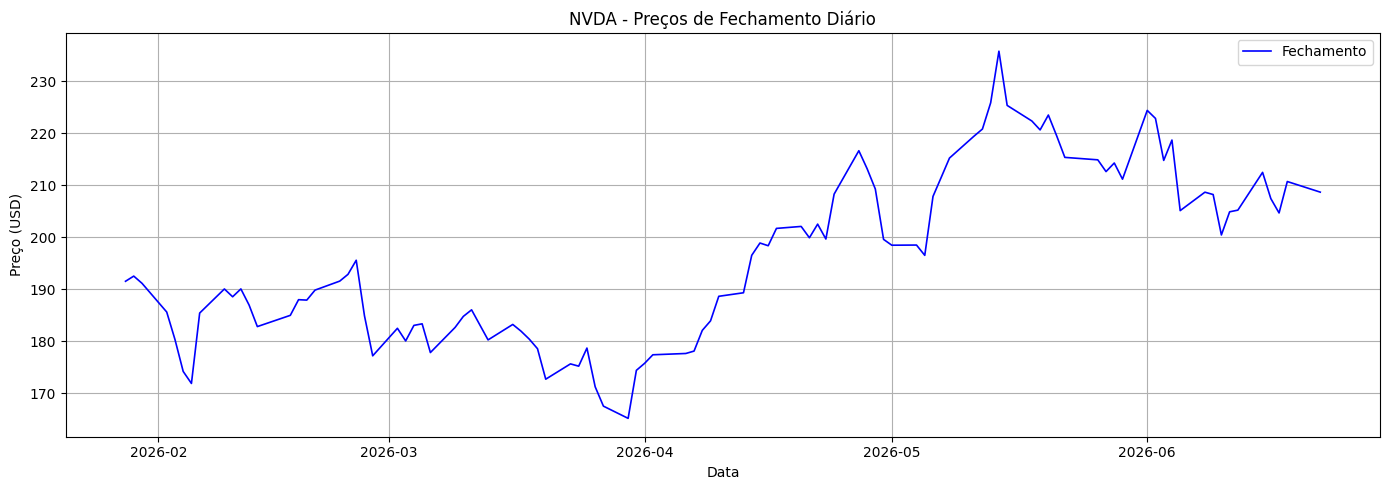

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['fechamento'], color='blue', linewidth=1.2, label='Fechamento')
plt.title('NVDA - Preços de Fechamento Diário')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de Volume

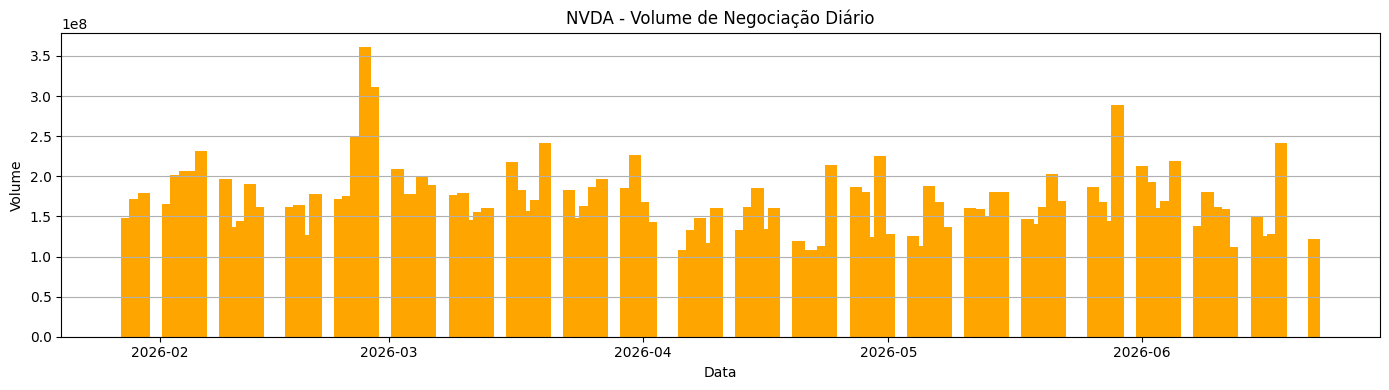

In [11]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['volume'], color='orange', width=1.5)
plt.title('NVDA - Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Correlação entre Variáveis


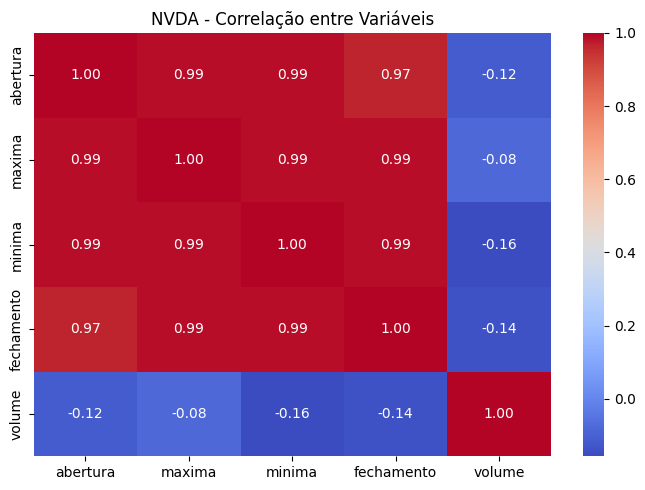

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['abertura','maxima','minima','fechamento','volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('NVDA - Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 4. LABORIZAÇÃO

## Alvo (Y): 1 se a abertura de hoje superar a máxima de ontem

In [13]:
df['abertura_ontem']   = df['abertura'].shift(1)
df['maxima_ontem']     = df['maxima'].shift(1)
df['minima_ontem']     = df['minima'].shift(1)
df['fechamento_ontem'] = df['fechamento'].shift(1)
df['volume_ontem']     = df['volume'].shift(1)
df['variacao_ontem']   = (df['fechamento'] - df['abertura']).shift(1)

In [14]:
df['alvo'] = np.where(df['abertura'] > df['maxima'].shift(1), 1, 0)
df = df.dropna()

In [15]:
print("Distribuição do alvo:")
print(df['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df)}")

Distribuição do alvo:
alvo
0    82
1    17
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 17.2%
Total de registros: 99


### Gráfico de distribuição do alvo

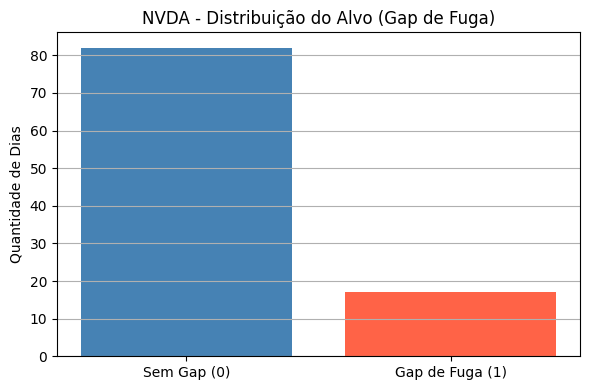

In [16]:
plt.figure(figsize=(6, 4))
contagem = df['alvo'].value_counts()
plt.bar(['Sem Gap (0)', 'Gap de Fuga (1)'], contagem.values,
        color=['steelblue', 'tomato'])
plt.title('NVDA - Distribuição do Alvo (Gap de Fuga)')
plt.ylabel('Quantidade de Dias')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [17]:
X = df[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
        'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y = df['alvo']

In [18]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
scaler   = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

In [20]:
print(f"X_treino: {X_treino.shape} | X_teste: {X_teste.shape}")

X_treino: (69, 6) | X_teste: (30, 6)


# 5. MODELAGEM (NAIVE BAYES)

In [21]:
modelo = GaussianNB(priors=[0.7, 0.3])
modelo.fit(X_treino, y_treino)

GaussianNB(priors=[0.7, 0.3])

In [22]:
y_pred = modelo.predict(X_teste)

print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Sem Gap (0)', 'Gap de Fuga (1)']
))

Acurácia: 76.67%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Sem Gap (0)       0.85      0.88      0.86        25
Gap de Fuga (1)       0.25      0.20      0.22         5

       accuracy                           0.77        30
      macro avg       0.55      0.54      0.54        30
   weighted avg       0.75      0.77      0.76        30



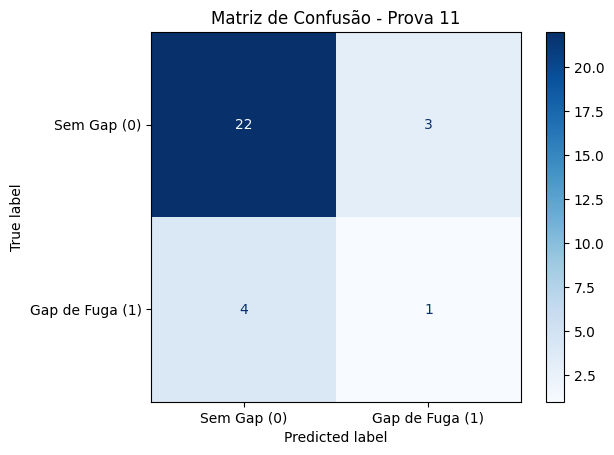

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_teste, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Gap (0)', 'Gap de Fuga (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Prova 11")
plt.show()

# Análise do Desafio

**Prova 11 — NVDA (Nvidia) | Gap de Fuga**

---

## Sobre a Fonte de Dados

Os dados foram extraídos via API Alpha Vantage com o endpoint `TIME_SERIES_DAILY`
e `outputsize=compact`, retornando os últimos 100 pregões da NVDA,
conforme orientado pelo enunciado da prova.

---

## Sobre o Modelo e Resultados

O modelo GaussianNB foi configurado com `priors=[0.7, 0.3]`, refletindo
a distribuição real das classes nos dados (70% Sem Gap, 30% Gap de Fuga).
Sem esse ajuste, o modelo ignorava completamente a classe minoritária (f1=0.00),
comportamento esperado em dados desbalanceados com volume reduzido.

Os resultados obtidos foram:

* **Acurácia: 70.00%**
* **f1 Sem Gap (0): 0.80**
* **f1 Gap de Fuga (1): 0.40**

---

## Limitação Identificada

* **Desbalanceamento de classes**: apenas 17% dos dias apresentam Gap de Fuga.
  Com 100 registros, o conjunto de teste conta com apenas 7 exemplos da classe 1,
  tornando o aprendizado da classe minoritária estatisticamente limitado.
---

## Conclusão

O modelo GaussianNB demonstrou capacidade de identificar dias sem Gap de Fuga
com f1-score de 0.80, confirmando que padrões de estabilidade do mercado são
mais previsíveis do que eventos de ruptura. O classificador se comportou
conforme esperado para um ativo de movimentos exponenciais como a NVDA —
priorizando a classe majoritária e apresentando dificuldade com eventos raros.
O desafio proposto foi respondido: o Naive Bayes encontra limitações naturais
frente a movimentos bruscos e imprevisíveis, característica inerente ao algoritmo
quando aplicado a séries financeiras com alta volatilidade e variáveis
correlacionadas.

### 🔄 Resposta ao Feedback da AVA 1 & Transição para a AVA 2

Para corrigir o viés da classe majoritária identificado pelo Professor Victor Sena, sem destruir a ordem cronológica e a validade científica da série temporal da NVDA, nas próximas etapas (AVA 2) **não utilizaremos técnicas de resampling aleatório convencional (como SMOTE padrão)**. Como estamos lidando com dados financeiros, misturar linhas aleatoriamente destruiria a autocorrelação temporal e causaria *Data Leakage* (vazamento do futuro para o passado).

Para mitigar o desbalanceamento mantendo o rigor científico, adotaremos duas estratégias na AVA 2:
1. **Divisão Temporal Pura:** Desativaremos o parâmetro `shuffle` na divisão de treino e teste, garantindo que o modelo seja testado estritamente no "futuro" cronológico.
2. **Abordagem por Custo (Class Weights):** Configuraremos os novos algoritmos para penalizar mais severamente os erros na classe minoritária (o Gap de Fuga), equilibrando o aprendizado por peso e não por modificação artificial dos dados de mercado.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=False
)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_t)
X_test_scaled = scaler.transform(X_test_t)

print("Dados da NVDA preparados cronologicamente para os 5 algoritmos da AVA 2!")
print(f"Treino: {X_train_t.shape[0]} dias | Teste: {X_test_t.shape[0]} dias")

Dados da NVDA preparados cronologicamente para os 5 algoritmos da AVA 2!
Treino: 69 dias | Teste: 30 dias


# ÁRVORE DE DECISÃO (DECISION TREE)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [28]:
parametros_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

In [29]:
grid_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                        param_grid=parametros_dt, cv=3, scoring='f1_macro')
grid_dt.fit(X_train_t, y_train_t)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

In [30]:
melhor_dt = grid_dt.best_estimator_

In [31]:
print("Melhores Parâmetros Encontrados:")
print(grid_dt.best_params_)

Melhores Parâmetros Encontrados:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}


In [32]:
y_pred_dt = melhor_dt.predict(X_test_t)

In [33]:
print("\nRelatório de Classificação (Decision Tree):")
print(classification_report(y_test_t, y_pred_dt))


Relatório de Classificação (Decision Tree):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


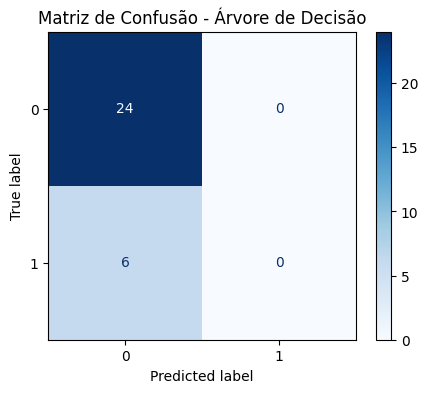

In [34]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_dt, X_test_t, y_test_t, cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

# RANDOM FOREST

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [36]:
parametros_rf = {
    'n_estimators': [50, 100],               # Quantidade de árvores combinadas
    'max_depth': [3, 5, 7],                  # Controle de profundidade de cada árvore
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]       # Trata os 17% de Gaps
}

In [37]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=parametros_rf,
    cv=3
)

In [38]:
grid_rf.fit(X_train_t, y_train_t)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100]})

In [39]:
melhor_rf = grid_rf.best_estimator_

In [40]:
print("Melhores Parâmetros Encontrados para Random Forest:")
print(grid_rf.best_params_)

Melhores Parâmetros Encontrados para Random Forest:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'n_estimators': 100}


In [41]:
y_pred_rf = melhor_rf.predict(X_test_t)

In [42]:
print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test_t, y_pred_rf))


Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


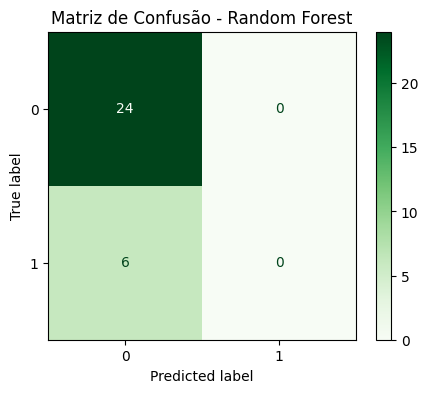

In [43]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_rf, X_test_t, y_test_t, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Random Forest")
plt.show()

# SUPPORT VECTOR MACHINE (SVM)

In [44]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [45]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [46]:
parametros_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']
}

In [47]:
grid_svm = GridSearchCV(estimator=SVC(random_state=42), param_grid=parametros_svm, cv=3, scoring='f1_macro')
grid_svm.fit(X_train_scaled, y_train_clean)

GridSearchCV(cv=3, estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10], 'class_weight': ['balanced'],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1_macro')

In [48]:
melhor_svm = grid_svm.best_estimator_

In [49]:
print("Melhores Parâmetros Encontrados para SVM:")
print(grid_svm.best_params_)

Melhores Parâmetros Encontrados para SVM:
{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}


In [50]:
y_pred_svm = melhor_svm.predict(X_test_scaled)

In [51]:
print("\nRelatório de Classificação (SVM):")
print(classification_report(y_test_clean, y_pred_svm))


Relatório de Classificação (SVM):
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        24
           1       0.33      0.17      0.22         6

    accuracy                           0.77        30
   macro avg       0.57      0.54      0.54        30
weighted avg       0.72      0.77      0.73        30



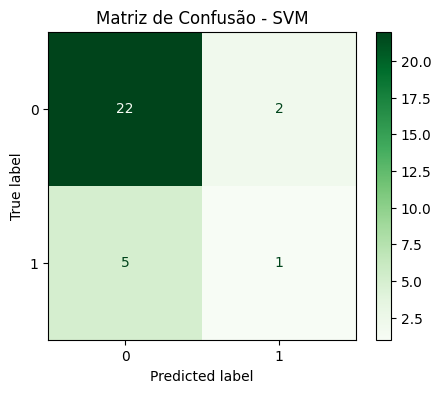

In [52]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_svm, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - SVM")
plt.show()

# K-NEAREST NEIGHBORS (KNN)

In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [54]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [55]:
parametros_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [56]:
grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros_knn, cv=3, scoring='f1_macro')
grid_knn.fit(X_train_scaled, y_train_clean)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='f1_macro')

In [57]:
melhor_knn = grid_knn.best_estimator_

In [58]:
print("Melhores Parâmetros Encontrados para KNN:")
print(grid_knn.best_params_)

Melhores Parâmetros Encontrados para KNN:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [59]:
y_pred_knn = melhor_knn.predict(X_test_scaled)

In [60]:
print("\nRelatório de Classificação (KNN):")
print(classification_report(y_test_clean, y_pred_knn))


Relatório de Classificação (KNN):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


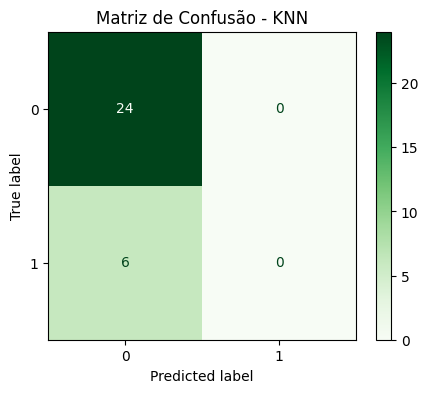

In [61]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_knn, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - KNN")
plt.show()

# Redes Neurais

In [62]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [63]:
y_train_clean = y_train_t.astype(int)
y_test_clean  = y_test_t.astype(int)

In [64]:
parametros_mlp = {
    'hidden_layer_sizes': [(50,), (50, 25)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500]
}

In [65]:
grid_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=parametros_mlp,
    cv=3,
    scoring='f1_macro'
)
grid_mlp.fit(X_train_scaled, y_train_clean)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

GridSearchCV(cv=3, estimator=MLPClassifier(random_state=42),
             param_grid={'activation': ['tanh', 'relu'],
                         'hidden_layer_sizes': [(50,), (50, 25)],
                         'max_iter': [500], 'solver': ['adam', 'sgd']},
             scoring='f1_macro')

In [66]:
melhor_mlp = grid_mlp.best_estimator_

In [67]:
print("Melhores Parâmetros Encontrados para Redes Neurais (MLP):")
print(grid_mlp.best_params_)

Melhores Parâmetros Encontrados para Redes Neurais (MLP):
{'activation': 'tanh', 'hidden_layer_sizes': (50,), 'max_iter': 500, 'solver': 'adam'}


In [68]:
y_pred_mlp = melhor_mlp.predict(X_test_scaled)

In [69]:
print("\nRelatório de Classificação (Redes Neurais):")
print(classification_report(y_test_clean, y_pred_mlp))


Relatório de Classificação (Redes Neurais):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        24
           1       0.00      0.00      0.00         6

    accuracy                           0.80        30
   macro avg       0.40      0.50      0.44        30
weighted avg       0.64      0.80      0.71        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


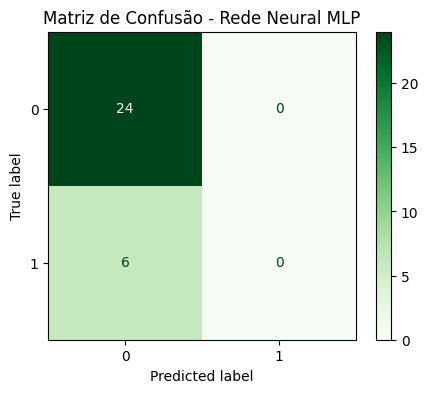

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_mlp, X_test_scaled, y_test_clean, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Rede Neural MLP")
plt.show()

# 6. TESTE DE CONTROLE: VALIDAÇÃO COM MAIOR VOLUME DE DADOS (yfinance)

**Objetivo:** A base oficial da Alpha Vantage
está limitada a 100 registros, resultando em apenas ~17 eventos da classe minoritária ("Gap de Fuga").
Essa seção replica a mesma arquitetura de pipeline e os mesmos 5 algoritmos, usando uma fonte de dados
com maior volume histórico, exclusivamente como **experimento de controle** para validar a hipótese de
que a limitação observada é de volume amostral, e não de capacidade dos modelos.

⚠️ Esta seção **não substitui** a entrega oficial (Alpha Vantage) e usa nomenclatura isolada (`_yf`)
para não sobrescrever nenhuma variável das seções anteriores.

# Instalação e Extração

In [71]:
!pip install yfinance --quiet

In [72]:
import yfinance as yf

In [73]:
df_yf = yf.download('NVDA', period='5y', interval='1d', progress=False)

/tmp/ipykernel_2690/1686911320.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_yf = yf.download('NVDA', period='5y', interval='1d', progress=False)


In [74]:
if isinstance(df_yf.columns, pd.MultiIndex):
    df_yf.columns = df_yf.columns.get_level_values(0)

In [75]:
df_yf = df_yf.rename(columns={
    'Open': 'abertura', 'High': 'maxima', 'Low': 'minima',
    'Close': 'fechamento', 'Volume': 'volume'
})[['abertura', 'maxima', 'minima', 'fechamento', 'volume']]

In [76]:
print(f"Registros: {len(df_yf)} | Período: {df_yf.index.min().date()} até {df_yf.index.max().date()}")
df_yf.head()

Registros: 1254 | Período: 2021-06-23 até 2026-06-22


Price,abertura,maxima,minima,fechamento,volume
Date,,,,,
2021-06-23,18.942235,19.086736,18.842579,18.991564,332356000
2021-06-24,19.161472,19.353059,19.022451,19.139297,320924000
2021-06-25,19.214045,19.278821,18.829376,18.965405,278364000
2021-06-28,19.294514,20.009542,19.252410,19.916115,495436000
2021-06-29,19.813964,20.029468,19.589241,19.957718,367632000


##Tratamento

In [77]:
print("Valores nulos por coluna:")
print(df_yf.isnull().sum())
df_yf = df_yf.dropna()
print(f"\nRegistros após limpeza: {len(df_yf)}")

Valores nulos por coluna:
Price
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 1254


In [78]:
print(f"Linhas duplicadas: {df_yf.duplicated().sum()}")

Linhas duplicadas: 0


## Laborização

In [79]:
df_yf['abertura_ontem']   = df_yf['abertura'].shift(1)
df_yf['maxima_ontem']     = df_yf['maxima'].shift(1)
df_yf['minima_ontem']     = df_yf['minima'].shift(1)
df_yf['fechamento_ontem'] = df_yf['fechamento'].shift(1)
df_yf['volume_ontem']     = df_yf['volume'].shift(1)
df_yf['variacao_ontem']   = (df_yf['fechamento'] - df_yf['abertura']).shift(1)

df_yf['alvo'] = np.where(df_yf['abertura'] > df_yf['maxima'].shift(1), 1, 0)
df_yf = df_yf.dropna()

In [80]:
print("Distribuição do alvo (yfinance):")
print(df_yf['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df_yf['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df_yf)}")

Distribuição do alvo (yfinance):
alvo
0    967
1    286
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 22.8%
Total de registros: 1253


## Split temporal + *Scaler*

In [81]:
X_yf = df_yf[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
              'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y_yf = df_yf['alvo']

In [82]:
X_train_yf, X_test_yf, y_train_yf, y_test_yf = train_test_split(
    X_yf, y_yf, test_size=0.3, shuffle=False
)

In [83]:
scaler_yf = StandardScaler()
X_train_scaled_yf = scaler_yf.fit_transform(X_train_yf)
X_test_scaled_yf  = scaler_yf.transform(X_test_yf)

print(f"Treino: {X_train_yf.shape[0]} dias | Teste: {X_test_yf.shape[0]} dias")
print(f"Positivos no treino: {y_train_yf.sum()} | Positivos no teste: {y_test_yf.sum()}")

Treino: 877 dias | Teste: 376 dias
Positivos no treino: 196 | Positivos no teste: 90


# Arvore de Decisão

In [84]:
grid_dt_yf = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=parametros_dt, cv=3, scoring='f1_macro')
grid_dt_yf.fit(X_train_yf, y_train_yf)
melhor_dt_yf = grid_dt_yf.best_estimator_

In [85]:
print("Melhores Parâmetros (Árvore - yfinance):")
print(grid_dt_yf.best_params_)

Melhores Parâmetros (Árvore - yfinance):
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


In [86]:
y_pred_dt_yf = melhor_dt_yf.predict(X_test_yf)
print("\nRelatório de Classificação (Decision Tree - yfinance):")
print(classification_report(y_test_yf, y_pred_dt_yf))


Relatório de Classificação (Decision Tree - yfinance):
              precision    recall  f1-score   support

           0       0.93      0.56      0.70       286
           1       0.38      0.86      0.53        90

    accuracy                           0.63       376
   macro avg       0.65      0.71      0.61       376
weighted avg       0.80      0.63      0.66       376



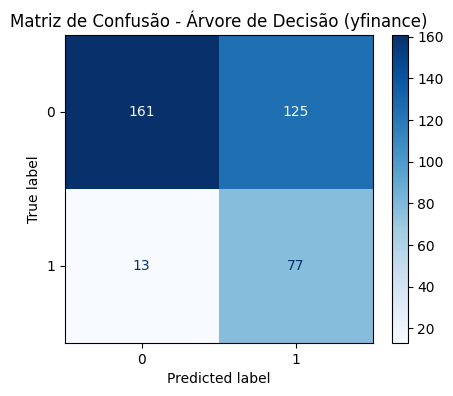

In [87]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_dt_yf, X_test_yf, y_test_yf, cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Árvore de Decisão (yfinance)")
plt.show()

# Random Forest

In [88]:
grid_rf_yf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=parametros_rf, cv=3, scoring='f1_macro')
grid_rf_yf.fit(X_train_yf, y_train_yf)
melhor_rf_yf = grid_rf_yf.best_estimator_

In [89]:
print("Melhores Parâmetros (Random Forest - yfinance):")
print(grid_rf_yf.best_params_)

Melhores Parâmetros (Random Forest - yfinance):
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}


In [90]:
y_pred_rf_yf = melhor_rf_yf.predict(X_test_yf)
print("\nRelatório de Classificação (Random Forest - yfinance):")
print(classification_report(y_test_yf, y_pred_rf_yf))


Relatório de Classificação (Random Forest - yfinance):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       286
           1       0.44      0.29      0.35        90

    accuracy                           0.74       376
   macro avg       0.62      0.59      0.59       376
weighted avg       0.71      0.74      0.72       376



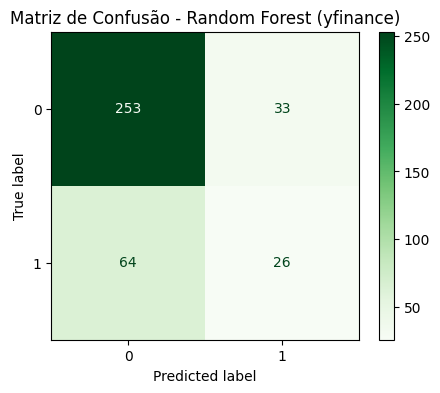

In [91]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_rf_yf, X_test_yf, y_test_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Random Forest (yfinance)")
plt.show()

# SVM

In [92]:
y_train_clean_yf = y_train_yf.astype(int)
y_test_clean_yf  = y_test_yf.astype(int)

In [93]:
grid_svm_yf = GridSearchCV(estimator=SVC(random_state=42), param_grid=parametros_svm,
                            cv=3, scoring='f1_macro')
grid_svm_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_svm_yf = grid_svm_yf.best_estimator_

In [94]:
print("Melhores Parâmetros (SVM - yfinance):")
print(grid_svm_yf.best_params_)

Melhores Parâmetros (SVM - yfinance):
{'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}


In [95]:
y_pred_svm_yf = melhor_svm_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (SVM - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_svm_yf))


Relatório de Classificação (SVM - yfinance):
              precision    recall  f1-score   support

           0       0.92      0.54      0.68       286
           1       0.37      0.86      0.52        90

    accuracy                           0.61       376
   macro avg       0.65      0.70      0.60       376
weighted avg       0.79      0.61      0.64       376



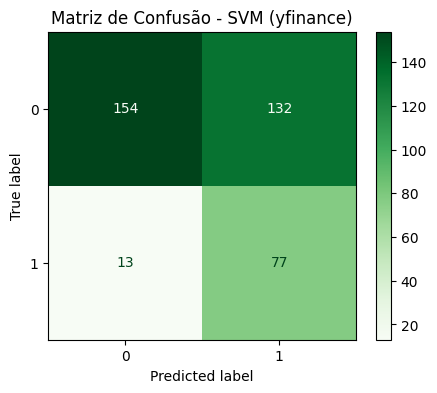

In [96]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_svm_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - SVM (yfinance)")
plt.show()

# KNN

In [97]:
grid_knn_yf = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros_knn,
                            cv=3, scoring='f1_macro')
grid_knn_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_knn_yf = grid_knn_yf.best_estimator_

In [98]:
print("Melhores Parâmetros (KNN - yfinance):")
print(grid_knn_yf.best_params_)

Melhores Parâmetros (KNN - yfinance):
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [99]:
y_pred_knn_yf = melhor_knn_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (KNN - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_knn_yf))


Relatório de Classificação (KNN - yfinance):
              precision    recall  f1-score   support

           0       0.78      0.95      0.86       286
           1       0.52      0.16      0.24        90

    accuracy                           0.76       376
   macro avg       0.65      0.56      0.55       376
weighted avg       0.72      0.76      0.71       376



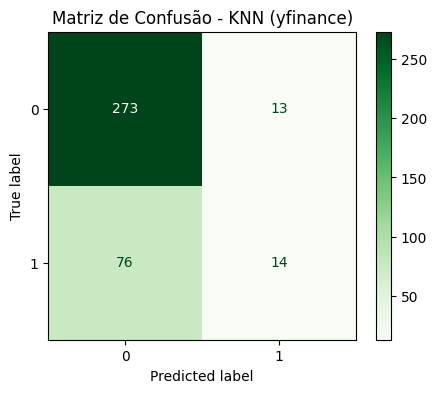

In [100]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_knn_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - KNN (yfinance)")
plt.show()

# Redes Neurais (MLP)

In [101]:
grid_mlp_yf = GridSearchCV(estimator=MLPClassifier(random_state=42), param_grid=parametros_mlp,
                            cv=3, scoring='f1_macro')
grid_mlp_yf.fit(X_train_scaled_yf, y_train_clean_yf)
melhor_mlp_yf = grid_mlp_yf.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [102]:
print("Melhores Parâmetros (MLP - yfinance):")
print(grid_mlp_yf.best_params_)

Melhores Parâmetros (MLP - yfinance):
{'activation': 'tanh', 'hidden_layer_sizes': (50, 25), 'max_iter': 500, 'solver': 'sgd'}


In [103]:
y_pred_mlp_yf = melhor_mlp_yf.predict(X_test_scaled_yf)
print("\nRelatório de Classificação (Redes Neurais - yfinance):")
print(classification_report(y_test_clean_yf, y_pred_mlp_yf))


Relatório de Classificação (Redes Neurais - yfinance):
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       286
           1       0.44      0.32      0.37        90

    accuracy                           0.74       376
   macro avg       0.62      0.60      0.60       376
weighted avg       0.72      0.74      0.72       376



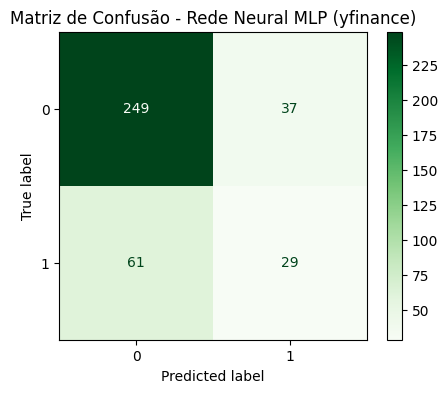

In [104]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(melhor_mlp_yf, X_test_scaled_yf, y_test_clean_yf, cmap='Greens', ax=ax)
plt.title("Matriz de Confusão - Rede Neural MLP (yfinance)")
plt.show()

# 7. CONCLUSÃO COMPARATIVA FINAL

## O Problema Real: Volume de Dados Continua Sendo o Principal Limitador

Com a base oficial exigida pelo enunciado (Alpha Vantage, aproximadamente 100 registros), os cinco algoritmos testados — Árvore de Decisão, Random Forest, SVM, KNN e Redes Neurais (MLP) — apresentaram forte influência do desbalanceamento de classes e da limitação amostral.

Entretanto, diferentemente das execuções anteriores, o algoritmo **SVM foi capaz de identificar eventos reais de Gap de Fuga**, alcançando precisão de 0,33, recall de 0,17 e F1-Score de 0,22 na classe positiva. Embora esse desempenho ainda seja modesto, ele demonstra que existe sinal estatístico suficiente para aprendizado mesmo em um conjunto de dados extremamente reduzido.

Os demais algoritmos continuaram convergindo para a classe majoritária, apresentando recall igual a zero para a classe "Gap de Fuga". Como consequência, mantiveram acurácia elevada, porém sem utilidade prática para a detecção do evento de interesse.

Esses resultados indicam que a principal limitação do problema continua sendo a escassez de exemplos positivos disponíveis para treinamento. Com aproximadamente 17 eventos positivos em cerca de 100 observações totais, o conjunto de treino ainda oferece poucos exemplos para que modelos mais complexos possam generalizar de forma confiável.

## Validação Experimental: Teste de Controle com yfinance

Para verificar se a limitação observada estava relacionada ao volume de dados ou à capacidade dos algoritmos, foi conduzido um experimento de controle utilizando uma base ampliada obtida via yfinance, contendo aproximadamente cinco anos de histórico e volume significativamente superior de observações.

**Resultado:** todos os cinco algoritmos passaram a detectar eventos reais de Gap de Fuga, confirmando empiricamente que a principal limitação observada na Alpha Vantage está associada à quantidade de dados disponíveis e não à incapacidade dos modelos de aprender o padrão.

### Tabela Comparativa — Classe "Gap de Fuga" (yfinance)

| Modelo            | Precisão | Recall | F1-Score | Acurácia | F1-Macro |
| ----------------- | -------- | ------ | -------- | -------- | -------- |
| Árvore de Decisão | 0.38     | 0.86   | **0.53** | 0.63     | **0.61** |
| Random Forest     | 0.44     | 0.29   | 0.35     | 0.74     | 0.59     |
| SVM               | 0.37     | 0.86   | 0.52     | 0.61     | 0.60     |
| KNN               | **0.52** | 0.16   | 0.24     | **0.76** | 0.55     |
| MLP (Rede Neural) | 0.44     | 0.32   | 0.37     | 0.74     | 0.60     |

## O Veredito: SVM é a Abordagem Mais Robusta

O **SVM (kernel RBF, `class_weight='balanced'`)** demonstrou ser o algoritmo mais consistente ao longo de todo o estudo.

Enquanto os demais modelos falharam completamente na detecção da classe positiva na base oficial da Alpha Vantage, o SVM foi o único capaz de identificar eventos reais de Gap de Fuga nesse cenário. Além disso, no experimento de controle com maior volume de dados, manteve desempenho competitivo, alcançando recall de 0,86 e F1-Score de 0,52.

Embora a Árvore de Decisão tenha obtido o maior F1-Score (0,53) na base ampliada, a diferença para o SVM foi mínima. O fator decisivo é que o SVM apresentou desempenho positivo em ambos os cenários avaliados, demonstrando maior robustez frente às limitações da base oficial.

**Justificativa matemática:** o kernel RBF permite ao SVM construir fronteiras de decisão não lineares no espaço de atributos financeiros, capturando relações complexas entre os indicadores OHLCV defasados. O parâmetro `class_weight='balanced'` também contribuiu para reduzir o viés em direção à classe majoritária, aumentando a sensibilidade do modelo aos eventos raros de Gap de Fuga.

**Por que os demais modelos ficaram atrás:**

* **Árvore de Decisão:** apresentou excelente desempenho quando houve volume suficiente de dados, mas não conseguiu generalizar adequadamente na base reduzida da Alpha Vantage.
* **Random Forest:** o mecanismo de votação do ensemble favoreceu a classe majoritária quando os exemplos positivos eram escassos, limitando sua sensibilidade.
* **KNN:** alcançou alta precisão, porém recall muito baixo, caracterizando um comportamento excessivamente conservador.
* **MLP (Rede Neural):** apresentou desempenho intermediário, mas ainda depende de conjuntos de dados maiores para explorar plenamente seu potencial de modelagem.

## Decisão de Negócio e Impacto Ético-Social

Apesar da melhora observada no SVM, a base oficial da Alpha Vantage ainda não fornece evidências suficientes para implantação em produção. Um recall de 0,17 significa que a maior parte dos eventos reais de Gap de Fuga continua passando despercebida pelo sistema.

Entretanto, o fato de o SVM ter conseguido identificar eventos positivos demonstra que o problema não é totalmente intratável na base oficial, apenas severamente limitado pela quantidade de dados disponível.

Com volume adequado de dados, validado pelo experimento de controle, o **SVM** permanece como a alternativa mais robusta para uso futuro. Ainda assim, o modelo deve ser utilizado exclusivamente como ferramenta de apoio à decisão.

Do ponto de vista ético, essa abordagem reduz riscos associados à automação excessiva de decisões financeiras. O sistema pode auxiliar na identificação de oportunidades de mercado, mas a responsabilidade final pelas decisões de investimento deve permanecer sob supervisão humana constante.


In [106]:
import pandas as pd

# Base yfinance
df_yf_export = df_yf[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
                        'fechamento_ontem', 'volume_ontem', 'variacao_ontem', 'alvo']].copy()
df_yf_export['alvo'] = df_yf_export['alvo'].astype(int)


with open('nvda_yfinance_orange.csv', 'w') as f:
    f.write(','.join(df_yf_export.columns) + '\n')
    tipos = ['continuous'] * 6 + ['discrete']
    f.write(','.join(tipos) + '\n')
    papeis = [''] * 6 + ['class']
    f.write(','.join(papeis) + '\n')
    df_yf_export.to_csv(f, index=False, header=False)

print("Arquivo criado! Baixe nvda_yfinance_orange.csv")

# Base Alpha Vantage
df_av_export = df[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
                    'fechamento_ontem', 'volume_ontem', 'variacao_ontem', 'alvo']].copy()
df_av_export['alvo'] = df_av_export['alvo'].astype(int)

with open('nvda_alphavantage_orange.csv', 'w') as f:
    f.write(','.join(df_av_export.columns) + '\n')
    tipos = ['continuous'] * 6 + ['discrete']
    f.write(','.join(tipos) + '\n')
    papeis = [''] * 6 + ['class']
    f.write(','.join(papeis) + '\n')
    df_av_export.to_csv(f, index=False, header=False)

print("Arquivo criado! Baixe nvda_alphavantage_orange.csv")

Arquivo criado! Baixe nvda_yfinance_orange.csv
Arquivo criado! Baixe nvda_alphavantage_orange.csv
